In [ ]:
#Link to dataset:
#https://collegescorecard.ed.gov/data/
#I'm wrangling/cleaning the 'Most Recent Cohorts Institution' csv

#Link to variable dictionary:
#https://collegescorecard.ed.gov/assets/InstitutionDataDocumentation.pdf

In [ ]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor

In [ ]:
#Load into dataframe
df = pd.read_csv("Most-Recent-Cohorts-Institution.csv")

df.head()

/tmp/ipykernel_3294/1800456889.py:2: DtypeWarning: Columns (9,1537,1540,1542,1547,1561,1589,1601,1602,1606,1608,1614,1615,1619,1620,1621,1622,1623,1624,1625,1626,1627,1628,1629,1725,1726,1727,1728,1729,1743,1815,1816,1817,1818,1823,1824,1830,1831,1879,1880,1881,1882,1883,1884,1885,1886,1887,1888,1889,1890,1891,1892,1893,1894,1895,1896,1897,1898,1909,1910,1911,1912,1913,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1983,1984,2376,2377,2403,2404,2495,2496,2497,2498,2499,2500,2501,2502,2503,2504,2505,2506,2507,2508,2509,2510,2511,2512,2513,2514,2515,2516,2517,2518,2519,2520,2521,2522,2523,2524,2525,2526,2527,2528,2529,2530,2958,3215,3231,3235,3236) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Most-Recent-Cohorts-Institution.csv")


,UNITID,OPEID,OPEID6,INSTNM,CITY,STABBR,ZIP,ACCREDAGENCY,INSTURL,NPCURL,...,MD_EARN_WNE_INC1_P11,MD_EARN_WNE_INC2_P11,MD_EARN_WNE_INC3_P11,MD_EARN_WNE_INDEP0_P11,MD_EARN_WNE_INDEP1_P11,MD_EARN_WNE_MALE0_P11,MD_EARN_WNE_MALE1_P11,SCORECARD_SECTOR,EARN_THR_STATE,EARN_THR_NAT
0,100654,100200.0,1002.0,Alabama A & M University,Normal,AL,35762,Southern Association of Colleges and Schools C...,www.aamu.edu/,www.aamu.edu/admissions-aid/tuition-fees/net-p...,...,36650.0,41070.0,47016.0,38892.0,41738.0,38167.0,40250.0,4,30168.0,32842
1,100663,105200.0,1052.0,University of Alabama at Birmingham,Birmingham,AL,35294-0110,Southern Association of Colleges and Schools C...,https://www.uab.edu/,https://tcc.ruffalonl.com/University of Alabam...,...,47182.0,51896.0,54368.0,50488.0,51505.0,46559.0,59181.0,4,30168.0,32842
2,100690,2503400.0,25034.0,Amridge University,Montgomery,AL,36117-3553,Southern Association of Colleges and Schools C...,https://www.amridgeuniversity.edu/,https://www2.amridgeuniversity.edu:9091/,...,35752.0,41007.0,NaN,NaN,38467.0,32654.0,49435.0,5,30168.0,32842
3,100706,105500.0,1055.0,University of Alabama in Huntsville,Huntsville,AL,35899,Southern Association of Colleges and Schools C...,www.uah.edu/,uah.clearcostcalculator.com/student/default/ne...,...,51208.0,62219.0,62577.0,55920.0,60221.0,47787.0,67454.0,4,30168.0,32842
4,100724,100500.0,1005.0,Alabama State University,Montgomery,AL,36104-0271,Southern Association of Colleges and Schools C...,www.alasu.edu/,tcc.ruffalonl.com/Alabama State University/Fre...,...,32844.0,36932.0,37966.0,34294.0,31797.0,32303.0,36964.0,4,30168.0,32842


In [ ]:
#If y'all need to search for a word in a column name
word = 'C100'
matching_cols = [col for col in df.columns if word.lower() in col.lower()]

print(matching_cols)

['C100_4', 'C100_L4', 'C100_4_POOLED', 'C100_L4_POOLED', 'C100_4_POOLED_SUPP', 'C100_L4_POOLED_SUPP']


In [ ]:
df.dtypes.to_dict()

{'UNITID': dtype('int64'),
 'OPEID': dtype('float64'),
 'OPEID6': dtype('float64'),
 'INSTNM': dtype('O'),
 'CITY': dtype('O'),
 'STABBR': dtype('O'),
 'ZIP': dtype('O'),
 'ACCREDAGENCY': dtype('O'),
 'INSTURL': dtype('O'),
 'NPCURL': dtype('O'),
 'SCH_DEG': dtype('float64'),
 'HCM2': dtype('int64'),
 'MAIN': dtype('int64'),
 'NUMBRANCH': dtype('int64'),
 'PREDDEG': dtype('int64'),
 'HIGHDEG': dtype('int64'),
 'CONTROL': dtype('int64'),
 'ST_FIPS': dtype('int64'),
 'REGION': dtype('int64'),
 'LOCALE': dtype('float64'),
 'LOCALE2': dtype('float64'),
 'LATITUDE': dtype('float64'),
 'LONGITUDE': dtype('float64'),
 'CCBASIC': dtype('float64'),
 'CCUGPROF': dtype('float64'),
 'CCSIZSET': dtype('float64'),
 'HBCU': dtype('float64'),
 'PBI': dtype('float64'),
 'ANNHI': dtype('float64'),
 'TRIBAL': dtype('float64'),
 'AANAPII': dtype('float64'),
 'HSI': dtype('float64'),
 'NANTI': dtype('float64'),
 'MENONLY': dtype('float64'),
 'WOMENONLY': dtype('float64'),
 'RELAFFIL': dtype('float64'),
 'A

In [ ]:
df.shape

(6322, 3308)

# Create refined df

In [ ]:
selected_columns = ['INSTNM', 'CITY', 'STABBR', 'ZIP', 'LATITUDE', 'LONGITUDE', 'CONTROL', 'UGDS',
                    'C150_4', 'GRAD_DEBT_MDN', 'COSTT4_A', 'TUITIONFEE_IN', 'TUITIONFEE_OUT',
                    'PCTPELL', 'MD_EARN_WNE_P10']

df_refined = df[selected_columns].copy()

In [ ]:
df_refined.head()

,INSTNM,CITY,STABBR,ZIP,LATITUDE,LONGITUDE,CONTROL,UGDS,C150_4,GRAD_DEBT_MDN,COSTT4_A,TUITIONFEE_IN,TUITIONFEE_OUT,PCTPELL,MD_EARN_WNE_P10
0,Alabama A & M University,Normal,AL,35762,34.783368,-86.568502,1,6124.0,0.2403,31000,27153.0,10024.0,18634.0,0.6298,40628.0
1,University of Alabama at Birmingham,Birmingham,AL,35294-0110,33.505697,-86.799345,1,11635.0,0.6423,22300,28145.0,9098.0,22562.0,0.3402,54501.0
2,Amridge University,Montgomery,AL,36117-3553,32.362609,-86.174010,2,241.0,1.0000,32189,NaN,7590.0,7590.0,0.7655,37621.0
3,University of Alabama in Huntsville,Huntsville,AL,35899,34.724557,-86.640449,1,6591.0,0.6429,20705,27392.0,12132.0,26408.0,0.2464,61767.0
4,Alabama State University,Montgomery,AL,36104-0271,32.364317,-86.295677,1,3477.0,0.3034,31000,23586.0,11248.0,19576.0,0.7134,34502.0


# Data Cleaning

In [ ]:
missing_data = df_refined.isnull()
missing_counts = missing_data.sum()
missing_percentages = (missing_counts / len(df_refined)) * 100

missing_summary = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_percentages.values
})

missing_summary = missing_summary.sort_values('Missing_Percentage', ascending=False)

print("Columns with missing data:")
print(missing_summary[missing_summary['Missing_Count'] > 0])

Columns with missing data:
             Column  Missing_Count  Missing_Percentage
8            C150_4           4039           63.888010
10         COSTT4_A           3092           48.908573
12   TUITIONFEE_OUT           2660           42.075293
11    TUITIONFEE_IN           2660           42.075293
14  MD_EARN_WNE_P10           1149           18.174628
13          PCTPELL            775           12.258779
7              UGDS            735           11.626068
4          LATITUDE            471            7.450174
5         LONGITUDE            471            7.450174
9     GRAD_DEBT_MDN            245            3.875356


Since COSTT4_A, TUITIONFEE_IN/_OUT have high missing values but could be integral to our analysis, I created a new column of imputated values that are like the row's.

In [ ]:
df_refined['COSTT4_A_IMP'] = df_refined.groupby('CONTROL')['COSTT4_A'].transform(lambda x: x.fillna(x.median()))
df_refined['TUITIONFEE_IN_IMP'] = df_refined.groupby('CONTROL')['TUITIONFEE_IN'].transform(lambda x: x.fillna(x.median()))
df_refined['TUITIONFEE_OUT_IMP'] = df_refined.groupby('CONTROL')['TUITIONFEE_OUT'].transform(lambda x: x.fillna(x.median()))


Since these 3 had lower NaN sums, I just did a median imputation to avoid any skewness.

In [ ]:
for col in ['MD_EARN_WNE_P10', 'PCTPELL', 'UGDS']:
    df_refined[col] = df_refined[col].fillna(df_refined[col].median())

Since LATITUDE, LONGITUDE, and GRAD_DEBT_MDN, I did not see a reason to do any imputation.

In [ ]:
missing_data = df_refined.isnull()
missing_counts = missing_data.sum()
missing_percentages = (missing_counts / len(df_refined)) * 100

missing_summary = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_percentages.values
})

missing_summary = missing_summary.sort_values('Missing_Percentage', ascending=False)

print("Columns with missing data:")
print(missing_summary[missing_summary['Missing_Count'] > 0])

Columns with missing data:
            Column  Missing_Count  Missing_Percentage
8           C150_4           4039           63.888010
10        COSTT4_A           3092           48.908573
11   TUITIONFEE_IN           2660           42.075293
12  TUITIONFEE_OUT           2660           42.075293
4         LATITUDE            471            7.450174
5        LONGITUDE            471            7.450174
9    GRAD_DEBT_MDN            245            3.875356


**Return On Investments columns:**
ROI: time to recover tuition cost for 4 years of college if you set aside 100% of your paycheck
- <1: less than one year until you make back cost
- 2: 2 years until you make back the cost

In [ ]:
#Create return on investments columns
df_refined['ROI'] = df_refined['COSTT4_A_IMP'] * 4 / df_refined['MD_EARN_WNE_P10']

Reorganizing columns

In [ ]:
columns = ['INSTNM', 'CITY', 'STABBR', 'CONTROL',
           'UGDS', 'C150_4', 'COSTT4_A', 'COSTT4_A_IMP',
           'TUITIONFEE_IN', 'TUITIONFEE_IN_IMP', 'TUITIONFEE_OUT', 'TUITIONFEE_OUT_IMP',
           'PCTPELL', 'GRAD_DEBT_MDN', 'MD_EARN_WNE_P10', 'ROI',
           'ZIP', 'LATITUDE', 'LONGITUDE']

df_refined = df_refined[columns]

In [ ]:
df_refined.head()

,INSTNM,CITY,STABBR,CONTROL,UGDS,C150_4,COSTT4_A,COSTT4_A_IMP,TUITIONFEE_IN,TUITIONFEE_IN_IMP,TUITIONFEE_OUT,TUITIONFEE_OUT_IMP,PCTPELL,GRAD_DEBT_MDN,MD_EARN_WNE_P10,ROI,ZIP,LATITUDE,LONGITUDE
0,Alabama A & M University,Normal,AL,1,6124.0,0.2403,27153.0,27153.0,10024.0,10024.0,18634.0,18634.0,0.6298,31000,40628.0,2.673329,35762,34.783368,-86.568502
1,University of Alabama at Birmingham,Birmingham,AL,1,11635.0,0.6423,28145.0,28145.0,9098.0,9098.0,22562.0,22562.0,0.3402,22300,54501.0,2.065650,35294-0110,33.505697,-86.799345
2,Amridge University,Montgomery,AL,2,241.0,1.0000,NaN,46093.0,7590.0,7590.0,7590.0,7590.0,0.7655,32189,37621.0,4.900774,36117-3553,32.362609,-86.174010
3,University of Alabama in Huntsville,Huntsville,AL,1,6591.0,0.6429,27392.0,27392.0,12132.0,12132.0,26408.0,26408.0,0.2464,20705,61767.0,1.773892,35899,34.724557,-86.640449
4,Alabama State University,Montgomery,AL,1,3477.0,0.3034,23586.0,23586.0,11248.0,11248.0,19576.0,19576.0,0.7134,31000,34502.0,2.734450,36104-0271,32.364317,-86.295677


In [ ]:
df_refined.shape

(6322, 19)

# Create df's for public and private colleges

In [ ]:
public_df = df_refined[df_refined['CONTROL'] == 1].copy()

In [ ]:
private_df = df_refined[df_refined['CONTROL'].isin([2, 3])].copy()

If you want to separate private and private nonprofit colleges into separate dfs:

In [ ]:
private_np_df = df_refined[df_refined['CONTROL'] == 2].copy()

In [ ]:
private_fp_df = df_refined[df_refined['CONTROL'] == 3].copy()

# Data Analyisis 1: Multiple Regression

For the regression model, we are going to predict the graduation rate and use debt, total cost of attendance, size, and student income as predictors. most of the other ones dont really work as important predictors, for example latitide and longditiude.

First creating a correlation matrix of the predictors we are using

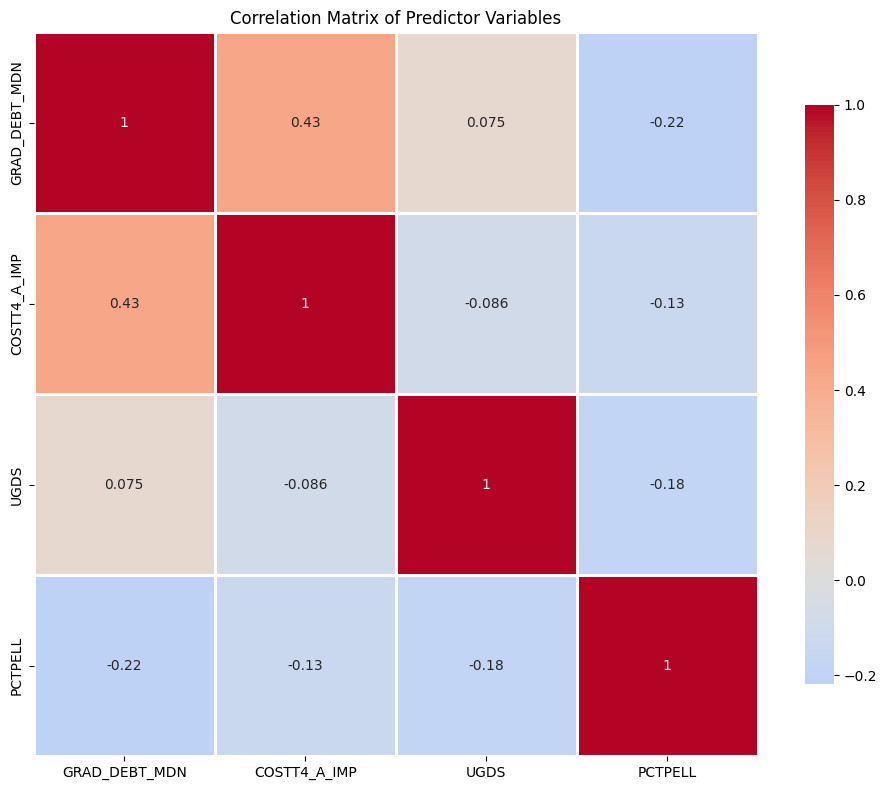

Correlation Matrix:
               GRAD_DEBT_MDN  COSTT4_A_IMP      UGDS   PCTPELL
GRAD_DEBT_MDN       1.000000      0.431603  0.075096 -0.218036
COSTT4_A_IMP        0.431603      1.000000 -0.085819 -0.132973
UGDS                0.075096     -0.085819  1.000000 -0.178313
PCTPELL            -0.218036     -0.132973 -0.178313  1.000000


In [ ]:
predictors = [
    'GRAD_DEBT_MDN',   # Median student debt
    'COSTT4_A_IMP',    # Total cost of attendance
    'UGDS',            # Enrollment size
    'PCTPELL'          # % low-income students
]

df_refined['GRAD_DEBT_MDN'] = pd.to_numeric(df_refined['GRAD_DEBT_MDN'], errors='coerce')


# Create correlation matrix
correlation_matrix = df_refined[predictors].corr()

# Visualize the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix of Predictor Variables')
plt.tight_layout()
plt.show()

# Print matrix
print("Correlation Matrix:")
print(correlation_matrix)


There are not any predictors with unusually high correlation (>0.7) leading to multicollinearity so these are the vaues we are going to use

Creating the multiple regression model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#Response variable = Graduation rate
response = 'C150_4'

# Prepare the data (remove missing values)
model_data = df_refined[predictors + [response]].dropna()

print(f"Using {len(model_data)} complete observations")
print(f"This represents {len(model_data)/len(df_refined)*100:.1f}% of the original data")

# Set up X and y
X_multiple = model_data[predictors]
y_multiple = model_data[response]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=42
)

# Create and fit the model
multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

# Display the coefficients
print(f"\nIntercept (β₀): {multiple_model.intercept_:.4f}")

print("\nCoefficients:")
for i, predictor in enumerate(predictors):
    print(f"  {predictor}: β_{i+1} = {multiple_model.coef_[i]:.6f}")

Using 2041 complete observations
This represents 32.3% of the original data

Intercept (β₀): 0.4468

Coefficients:
  GRAD_DEBT_MDN: β_1 = -0.000005
  COSTT4_A_IMP: β_2 = 0.000006
  UGDS: β_3 = 0.000004
  PCTPELL: β_4 = -0.198574


The small coefficients for cost and debt may also be influenced by differences in scale, since these variables are measured in large units (dollars), making their coefficients appear small even if they have meaningful effects.

RSME, R^2 and predicted vs actual

In [ ]:
from sklearn.metrics import r2_score

# Make predictions on test set
y_pred_multiple = multiple_model.predict(X_test)

# Calculate R²
r2_multiple = r2_score(y_test, y_pred_multiple)
print(f"R² Score: {r2_multiple:.4f}")

# RMSE STEP-BY-STEP

# Step 1: Create dataframe with actual vs predicted
results_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred_multiple
})

# Step 2: Calculate residuals (difference)
results_df['difference'] = results_df['actual'] - results_df['predicted']

# Step 3: Square the differences
results_df['squared_difference'] = results_df['difference'] ** 2

# Step 4: Mean Squared Error (MSE)
mse = results_df['squared_difference'].mean()

# Step 5: Root Mean Squared Error (RMSE)
rmse_multiple = np.sqrt(mse)

print(f"RMSE: {rmse_multiple:.4f}")

# Show predictions
print("\nSample predictions:")
print(results_df.head(10))

R² Score: 0.4024
RMSE: 0.1615

Sample predictions:
   actual  predicted  difference  squared_difference
0  0.2574   0.420173   -0.162773            0.026495
1  0.7354   0.787958   -0.052558            0.002762
2  0.3846   0.345785    0.038815            0.001507
3  1.0000   0.474579    0.525421            0.276067
4  0.5296   0.440667    0.088933            0.007909
5  0.0000   0.444776   -0.444776            0.197826
6  0.4504   0.580333   -0.129933            0.016883
7  0.7832   0.768538    0.014662            0.000215
8  0.3514   0.464168   -0.112768            0.012717
9  0.7392   0.638148    0.101052            0.010211


The model achieved an R^2 value of 0.4024, meaning it explains about 40% of the variation in graduation rates, which indicates a moderate fit. The RMSE of 0.1615 shows that predictions are off by about 0.16 (16 percentage points) on average, reflecting moderate prediction error. Overall, the model captures meaningful relationships but still misses some factors influencing graduation outcomes, since R^2 measures explained variation and RMSE measures average prediction error

Model vs Actual

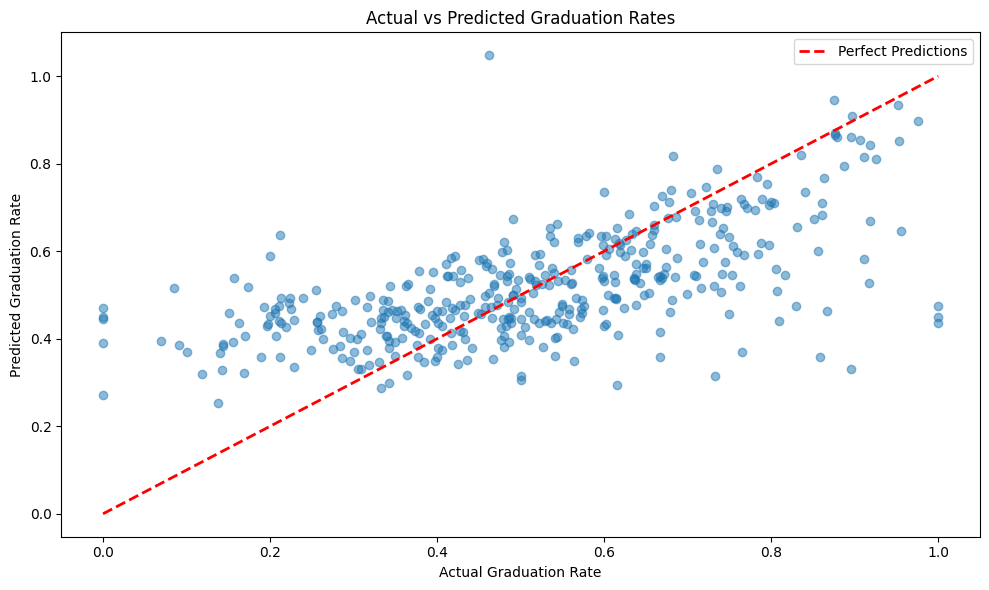

In [ ]:
# Create a scatter plot of actual vs predicted values
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_multiple, alpha=0.5)

# Perfect prediction line (y = x)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Predictions'
)

plt.xlabel('Actual Graduation Rate')
plt.ylabel('Predicted Graduation Rate')
plt.title('Actual vs Predicted Graduation Rates')

plt.legend()
plt.tight_layout()
plt.show()

Residual plot

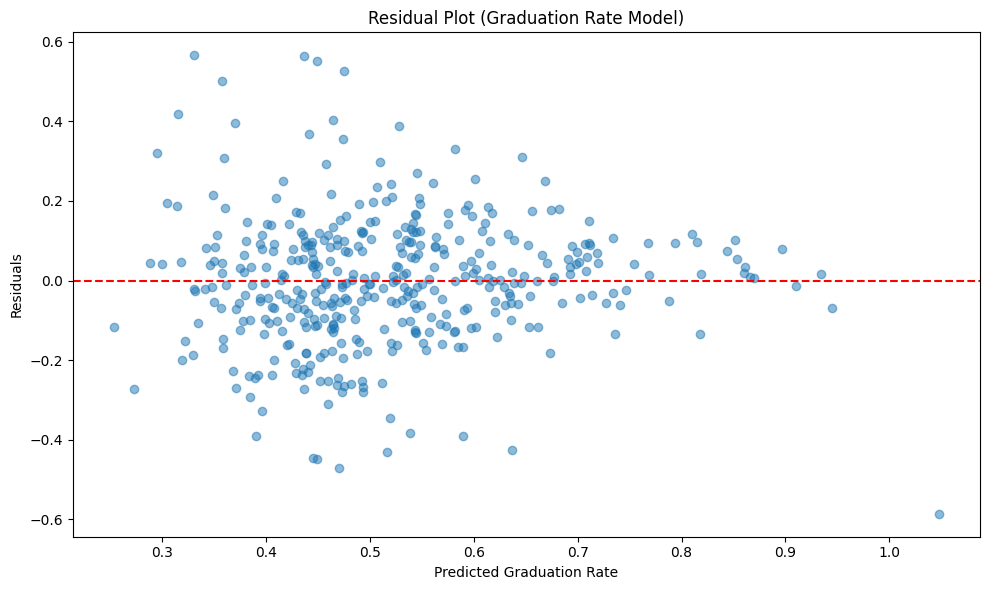

Residual Statistics:
Mean: -0.0019
Standard Deviation: 0.1617


In [ ]:

# Create residuals
residuals = y_test - y_pred_multiple

# Create residual plot
plt.figure(figsize=(10, 6))

plt.scatter(y_pred_multiple, residuals, alpha=0.5)

# Horizontal line at 0
plt.axhline(y=0, color='r', linestyle='--')

plt.xlabel('Predicted Graduation Rate')
plt.ylabel('Residuals')
plt.title('Residual Plot (Graduation Rate Model)')

plt.tight_layout()
plt.show()

# Summary statistics of residuals
print("Residual Statistics:")
print(f"Mean: {residuals.mean():.4f}")
print(f"Standard Deviation: {residuals.std():.4f}")

# Data Analysis 2: Clustering

First we need to standardize the variables

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Your features
features_to_use = [
    'GRAD_DEBT_MDN',
    'COSTT4_A_IMP',
    'UGDS',
    'PCTPELL'
]


# Extract selected features and drop missing values
X = df_refined[features_to_use].dropna()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to dataframe for readability
scaled_df = pd.DataFrame(X_scaled, columns=features_to_use)

print("Sample of standardized features:")
print(scaled_df.head(10))

Sample of standardized features:
   GRAD_DEBT_MDN  COSTT4_A_IMP      UGDS   PCTPELL
0       1.990964     -0.364543  0.471474  1.031446
1       0.850939     -0.300480  1.274870 -0.486205
2       2.146767      0.858598 -0.386152  1.742583
3       0.641935     -0.349109  0.539553 -0.977764
4       1.990964     -0.594899  0.085593  1.469552
5       0.909906      0.037724  4.422561 -1.304772
6      -0.791482     -0.735231 -0.245912 -0.600972
7       0.294162     -0.969656 -0.064707 -0.041286
8       1.204740     -0.739106 -0.050712 -0.049671
9       0.680591      0.136983  3.487962 -1.612389


In [ ]:
# Compare original vs scaled data statistics
print("Original Data Statistics:")
print(df_refined[features_to_use].describe())
print("\nScaled Data Statistics:")
print(scaled_df.describe())

Original Data Statistics:
       GRAD_DEBT_MDN  COSTT4_A_IMP           UGDS      PCTPELL
count    4815.000000   6322.000000    6322.000000  6322.000000
mean    15806.127310  32149.534957    2353.886428     0.427817
std      7632.208102  14817.607221    6119.768742     0.203138
min      2783.000000   4451.000000       0.000000     0.000000
25%      9500.000000  19855.750000     147.000000     0.287450
50%     13432.000000  31946.000000     540.000000     0.398400
75%     22500.000000  36982.500000    1794.250000     0.558450
max     43021.000000  93512.000000  163164.000000     1.000000

Scaled Data Statistics:
       GRAD_DEBT_MDN  COSTT4_A_IMP          UGDS      PCTPELL
count   4.815000e+03  4.815000e+03  4.815000e+03  4815.000000
mean   -4.722195e-17  1.652768e-16 -2.361097e-17     0.000000
std     1.000104e+00  1.000104e+00  1.000104e+00     1.000104
min    -1.706515e+00 -1.648971e+00 -4.212856e-01    -2.269025
25%    -8.263378e-01 -7.336167e-01 -3.891410e-01    -0.736963
50%    -3.

now using the elbow method to find optimal amount of clusters

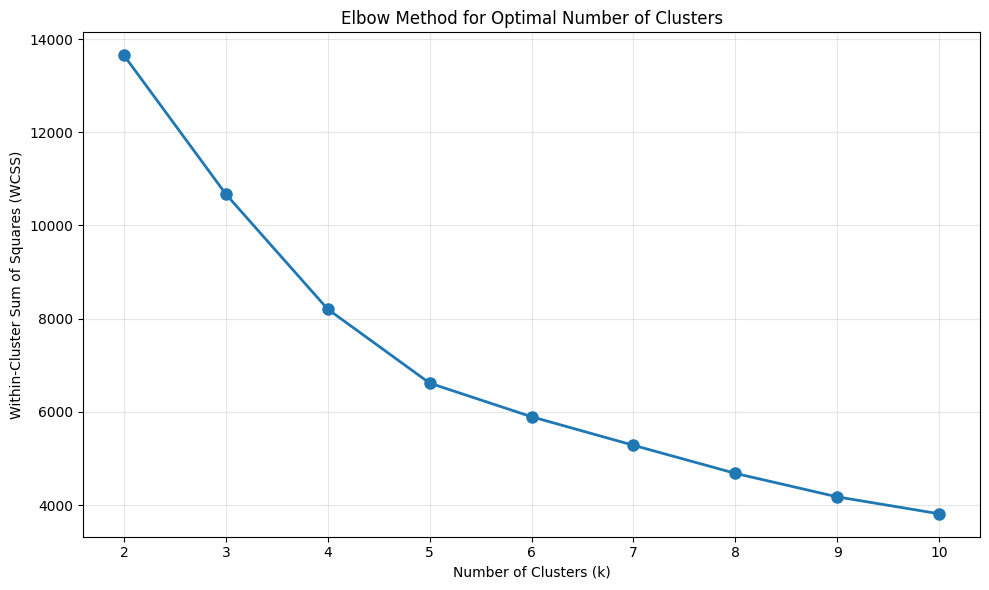

In [ ]:
from sklearn.cluster import KMeans

# Calculate WCSS (Within-Cluster Sum of Squares)
wcss = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))

plt.plot(k_range, wcss, marker='o', linewidth=2, markersize=8)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal Number of Clusters')

plt.grid(True, alpha=0.3)
plt.xticks(k_range)

plt.tight_layout()
plt.show()

we will use 5 clusters for our analysis

now we will also use the silhouette method to see what the best defined clusters are

For k = 2, silhouette score = 0.3439
For k = 3, silhouette score = 0.3308
For k = 4, silhouette score = 0.3446
For k = 5, silhouette score = 0.3475
For k = 6, silhouette score = 0.3499
For k = 7, silhouette score = 0.3085
For k = 8, silhouette score = 0.3102
For k = 9, silhouette score = 0.3258
For k = 10, silhouette score = 0.3225


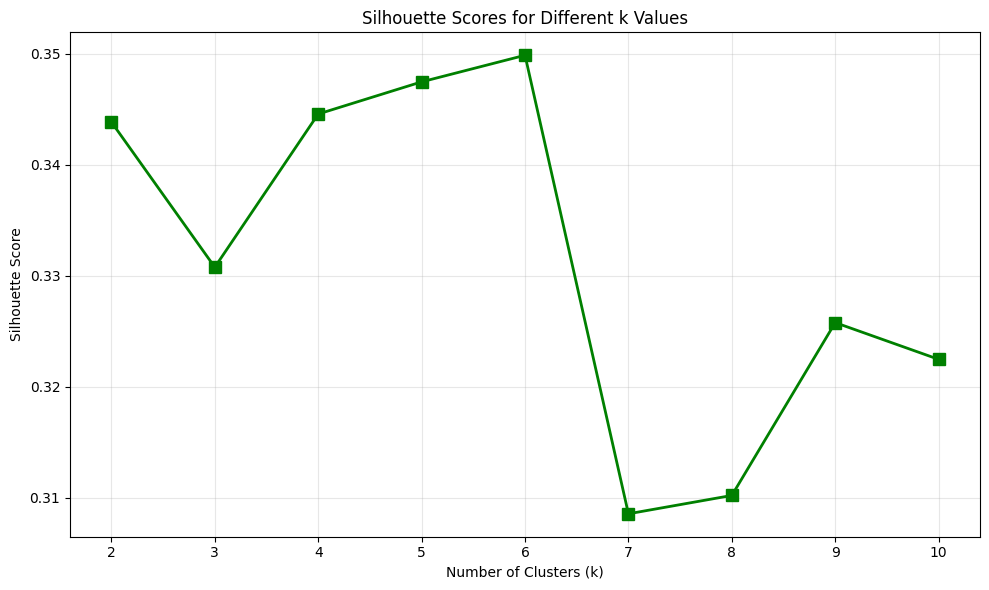

In [ ]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Calculate silhouette scores for different numbers of clusters
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    print(f"For k = {k}, silhouette score = {silhouette_avg:.4f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))

plt.plot(k_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='green')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k Values')

plt.grid(True, alpha=0.3)
plt.xticks(k_range)

plt.tight_layout()
plt.show()

The 2 methods pretty well agree so we will do 5 clusters in our analysis

K-Means analysis

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set the number of clusters based on your analysis
n_clusters = 5

# Train the K-means model
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)


cluster_data = X.copy()  # use the cleaned data you clustered on
cluster_data['cluster'] = cluster_labels

# Display cluster distribution
print("\nCluster distribution:")
print(cluster_data['cluster'].value_counts().sort_index())

# Calculate silhouette score for final model
final_silhouette = silhouette_score(X_scaled, cluster_labels)
print(f"\nFinal Silhouette Score: {final_silhouette:.4f}")


Cluster distribution:
cluster
0    1291
1    1294
2    1482
3     172
4     576
Name: count, dtype: int64

Final Silhouette Score: 0.3475


Cluster visualization with PCA

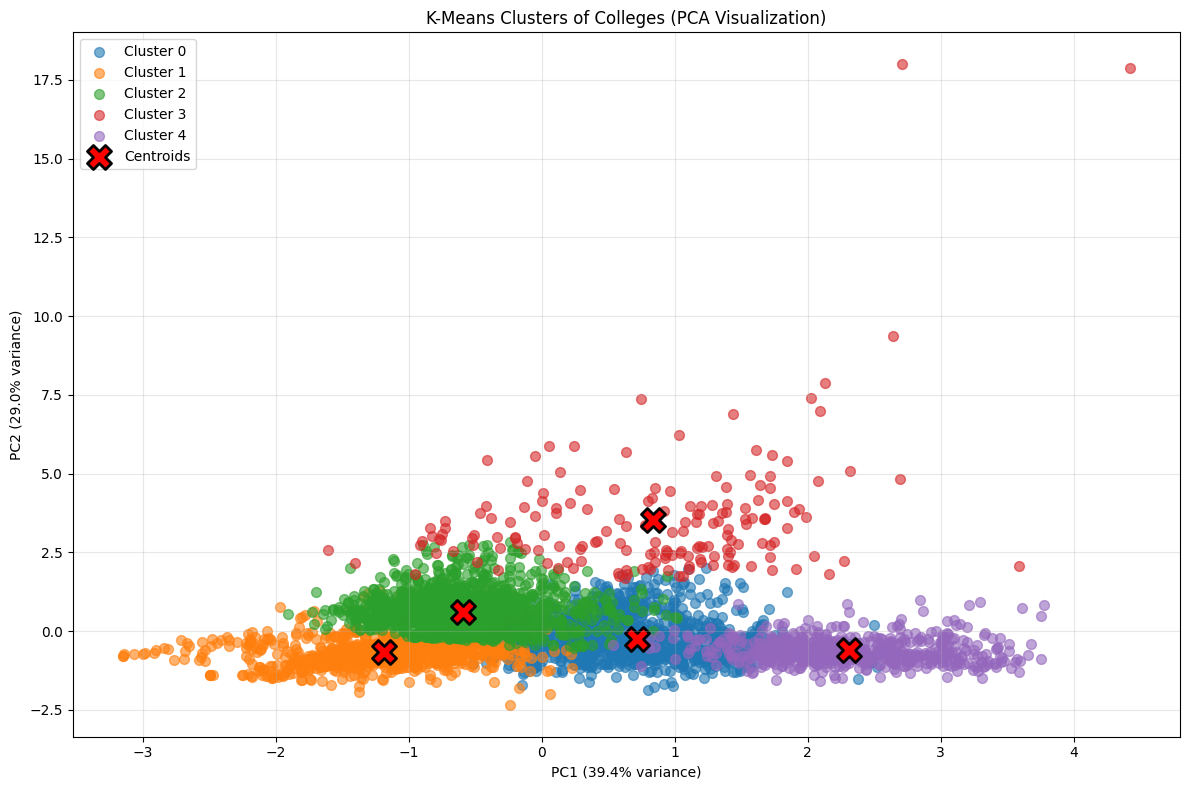


Total variance explained by first 2 components: 68.4%


In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a dataframe with PCA results
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'cluster': cluster_labels
})

# Plot the clusters
plt.figure(figsize=(12, 8))

for cluster in range(n_clusters):
    cluster_subset = pca_df[pca_df['cluster'] == cluster]  # renamed to avoid overwriting
    plt.scatter(
        cluster_subset['PC1'],
        cluster_subset['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.6,
        s=50
    )

# Plot cluster centers (converted into PCA space)
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c='red',
    marker='X',
    s=300,
    edgecolors='black',
    linewidths=2,
    label='Centroids'
)

# Labels and formatting
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('K-Means Clusters of Colleges (PCA Visualization)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print explained variance
print(f"\nTotal variance explained by first 2 components: {sum(pca.explained_variance_ratio_):.1%}")

analyzing the cluster means

In [ ]:
# Calculate mean feature values for each cluster
cluster_means = cluster_data.groupby('cluster')[features_to_use].mean()

print("Mean feature values for each cluster:")
print(cluster_means.round(3))

Mean feature values for each cluster:
         GRAD_DEBT_MDN  COSTT4_A_IMP       UGDS  PCTPELL
cluster                                                 
0            23944.477     33649.414   2176.593    0.424
1            10135.703     30758.309    521.105    0.666
2            10441.760     22160.976   2529.055    0.323
3            17374.558     26252.035  30048.924    0.307
4            23637.969     64793.557   2628.349    0.251


The clusters show clear differences in cost, debt, and student demographics across institutions. For example, Cluster 4 represents high-cost, high-debt schools with lower Pell Grant percentages, while Cluster 1 consists of lower-cost schools serving a higher proportion of low-income students. Overall, the clustering reveals distinct types of colleges, ranging from more elite, expensive institutions to more accessible, lower-cost schools with different student populations.

Radar plots for the clusters

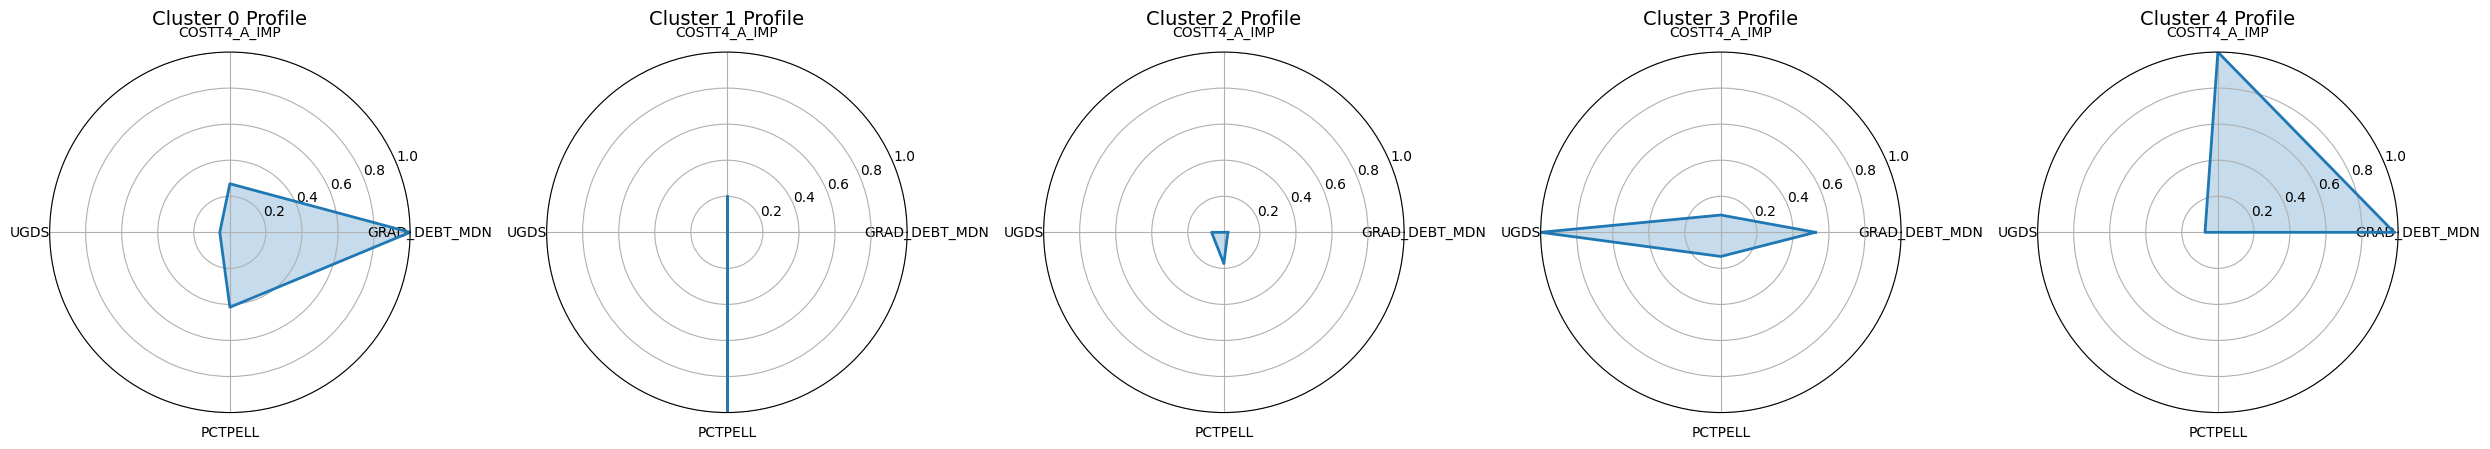

In [ ]:
# Number of features
num_features = len(features_to_use)

# Angles for radar chart
angles = np.linspace(0, 2*np.pi, num_features, endpoint=False).tolist()
angles += angles[:1]  # complete circle

# Create subplots
fig, axes = plt.subplots(1, n_clusters, figsize=(n_clusters*5, 5),
                         subplot_kw=dict(polar=True))

# Fix for single cluster case
if n_clusters == 1:
    axes = [axes]

# Normalize cluster means (VERY IMPORTANT for radar chart)
cluster_means_normalized = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

# Plot each cluster
for i, ax in enumerate(axes):
    values = cluster_means_normalized.iloc[i].values.tolist()
    values += values[:1]  # complete circle

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features_to_use, fontsize=10)

    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {i} Profile', fontsize=14, pad=20)

    ax.grid(True)

plt.tight_layout()
plt.show()

# Data Visualizations

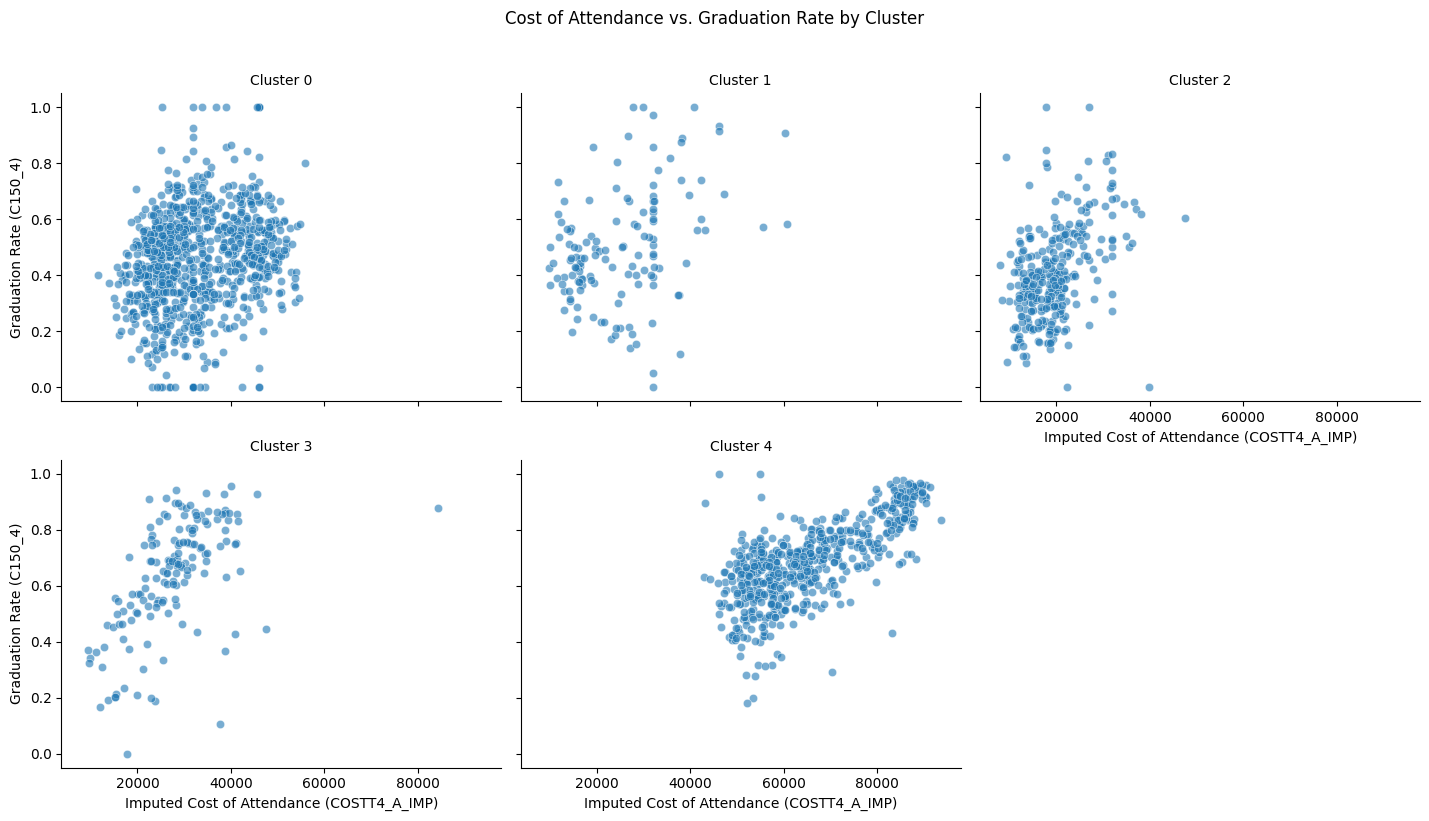

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# The `X` DataFrame contains the features used for clustering and retains the original index from `df_refined`.
# Add the cluster labels to this DataFrame.
X_with_clusters = X.copy()
X_with_clusters['cluster'] = cluster_labels

# Now, merge `C150_4` from `df_refined` back into this DataFrame using the index.
# We need to ensure C150_4 values are aligned with the correct clustered data.
plot_data_clustered = X_with_clusters.merge(
    df_refined[['C150_4']],
    left_index=True,
    right_index=True,
    how='left'
)

# Drop any rows where 'C150_4' is NaN, as these cannot be plotted.
plot_data_clustered = plot_data_clustered.dropna(subset=['C150_4'])

# Create a FacetGrid for scatter plots by cluster
g = sns.relplot(
    data=plot_data_clustered,
    x='COSTT4_A_IMP',
    y='C150_4',
    col='cluster',
    col_wrap=3,
    height=4,
    aspect=1.2,
    kind='scatter',
    alpha=0.6
)

g.set_axis_labels('Imputed Cost of Attendance (COSTT4_A_IMP)', 'Graduation Rate (C150_4)')
g.set_titles('Cluster {col_name}')
g.fig.suptitle('Cost of Attendance vs. Graduation Rate by Cluster', y=1.02) # Adjust title position

plt.tight_layout()
plt.show()

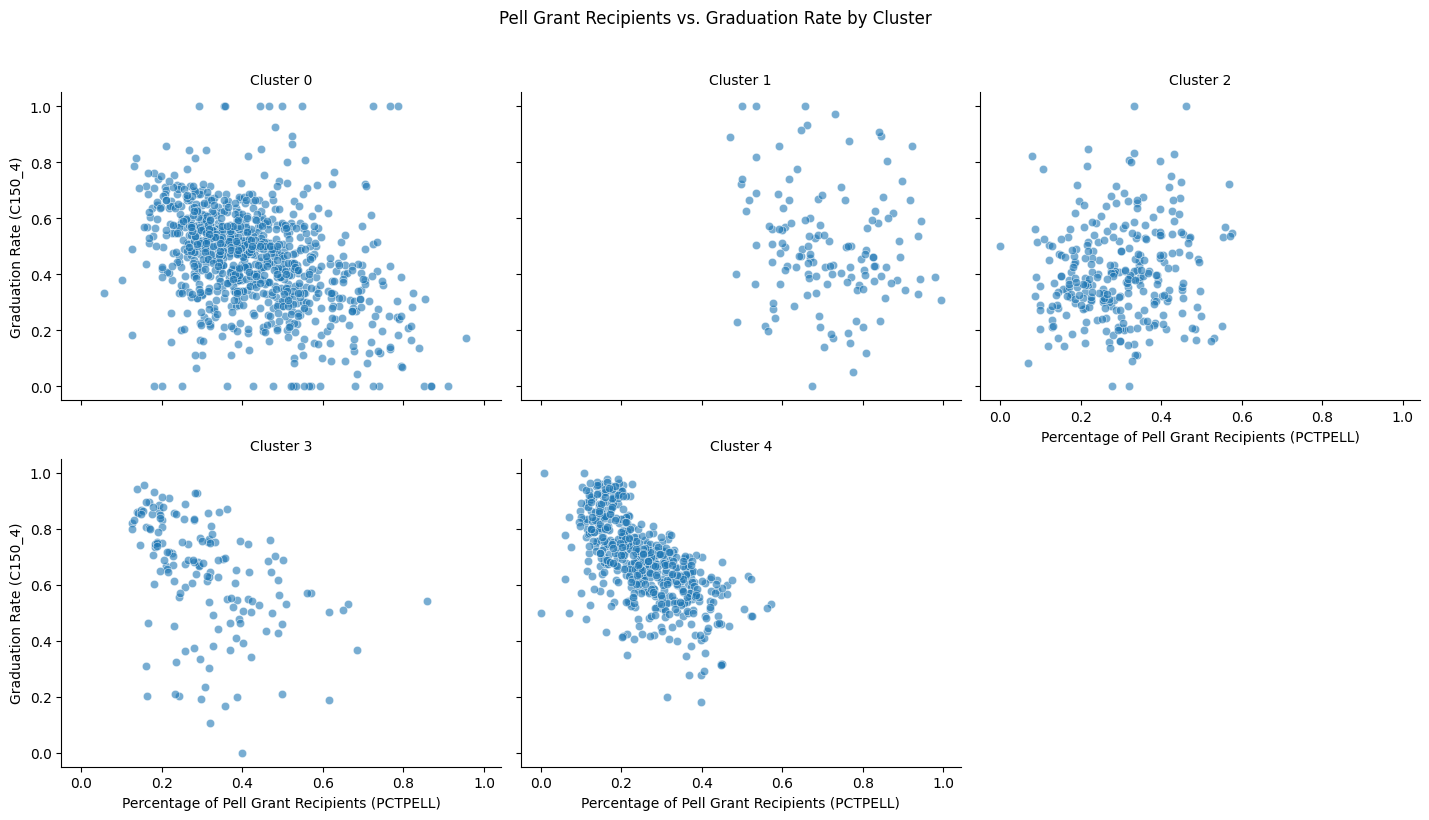

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# The `X` DataFrame contains the features used for clustering and retains the original index from `df_refined`.
# Add the cluster labels to this DataFrame.
X_with_clusters = X.copy()
X_with_clusters['cluster'] = cluster_labels

# Now, merge `C150_4` from `df_refined` back into this DataFrame using the index.
# We need to ensure C150_4 values are aligned with the correct clustered data.
plot_data_clustered = X_with_clusters.merge(
    df_refined[['C150_4']],
    left_index=True,
    right_index=True,
    how='left'
)

# Drop any rows where 'C150_4' is NaN, as these cannot be plotted.
plot_data_clustered = plot_data_clustered.dropna(subset=['C150_4'])

# Create a FacetGrid for scatter plots by cluster
g = sns.relplot(
    data=plot_data_clustered,
    x='PCTPELL',
    y='C150_4',
    col='cluster',
    col_wrap=3,
    height=4,
    aspect=1.2,
    kind='scatter',
    alpha=0.6
)

g.set_axis_labels('Percentage of Pell Grant Recipients (PCTPELL)', 'Graduation Rate (C150_4)')
g.set_titles('Cluster {col_name}')
g.fig.suptitle('Pell Grant Recipients vs. Graduation Rate by Cluster', y=1.02) # Adjust title position

plt.tight_layout()
plt.show()

make the csv file

In [ ]:
df_refined.to_csv("cleanData.csv", index=False)